# Classificador Naive Bayes

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

No classificador Naive Bayes, podemos assumir que os atributos são normalmente distribuídos.

In [60]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/iris.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################


data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Número de linhas e colunas na matriz de atributos: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [61]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionando os conjuntos de treinamento e teste.

In [62]:
from sklearn.model_selection import train_test_split
p = 0.7 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

### Classificação: implementação do método

Inicialmente, definimos uma função para calcular a densidade de probabilidade conjunta: $$p(\vec{x}|C_i) = \prod_{j=1}^d p(x_j|C_i), \quad i=1,\ldots, k$$
onde $C_i$ são as classes. Se a distribuição for normal, temos que cada atributo $X_j$ tem a seguinte função densidade de probabilidade associada, para cada classe:
$$
p(x_j|C_i) = \frac{1}{\sqrt{2\pi\sigma_{C_i}}}\exp \left[ -\frac{1}{2}\left( \frac{x_j-\mu_{C_i}}{\sigma_{C_i}}\right)^2 \right], \quad i=1,2,\ldots, k.
$$
Assim, definimos uma função para calcular a função de verossimilhança.

In [63]:
def likelyhood(y, Z):
    def gaussian(x, mu, sig):
        p = (1/np.sqrt(2*np.pi*sig))*np.exp((-1/2)*((x-mu)/sig)**2)
        return p
    lk = 1
    for j in np.arange(0, Z.shape[1]):
        m = np.mean(Z[:,j])
        s = np.std(Z[:,j])
        lk = lk*gaussian(y[j], m, s)
    return lk

A seguir, realizamos a estimação para cada classe:

In [64]:
P = pd.DataFrame(data=np.zeros((X_test.shape[0], len(classes))), columns = classes)
for i in np.arange(0, len(classes)):
    elements = tuple(np.where(y_train == classes[i]))
    Z = X_train[elements,:][0]
    for j in np.arange(0,X_test.shape[0]):
        x = X_test[j,:]
        pj = likelyhood(x,Z)
        priori = len(elements)/X_train.shape[0]
        #P[classes[i]][j] = pj*priori
        P.loc[j, classes[i]] = pj*priori

Para as observações no conjunto de teste, a probabilidade pertencer a cada classe:

In [65]:
P.head(10)

,setosa,versicolor,virginica
0,9.264390e-91,9.058657e-04,5.839773e-06
1,8.390494e-05,2.441540e-17,5.930127e-24
2,3.423655e-287,6.325415e-18,3.360242e-06
3,8.173128e-94,8.247540e-04,3.052037e-05
4,1.245699e-106,1.643730e-04,4.766081e-05
5,7.571647e-04,1.088426e-15,1.647681e-23
6,8.051944e-54,6.590165e-04,3.411812e-08
7,2.877750e-172,1.401158e-10,4.718933e-04
8,1.714072e-96,1.713425e-04,1.589254e-06
9,3.994861e-60,1.383185e-03,9.352542e-08


In [66]:
from sklearn.metrics import accuracy_score

y_pred = []
for i in np.arange(0, P.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(P.columns[c])
y_pred = np.array(y_pred, dtype=str)

score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.9777777777777777


### Classificação: usando a biblioteca scikit-learn

Podemos realizar a classificação usando a função disponível na biblioteca scikit-learn.

In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.9777777777777777


Código completo.

In [68]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

random.seed(42)

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
file_path = '/content/drive/MyDrive/data/iris.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Transforma os dados para terem media igual a zero e variancia igual a 1
#scaler = StandardScaler().fit(X)
#X = scaler.transform(X)

# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = p, random_state = 42)

# ajusta o classificador Naive-Bayes de acordo com os dados
model = GaussianNB()
model.fit(X_train, y_train)
# realiza a predicao
y_pred = model.predict(X_test)
# calcula a acuracia
score = accuracy_score(y_pred, y_test)
print('Acuracia:', score)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Acuracia: 1.0


## Região de decisão

Selecionando dois atributos, podemos visualizar a região de decisão. Para graficar a região de separação, precisamos instalar a bibliteca mlxtend: http://rasbt.github.io/mlxtend/installation/<br>
Pode ser usado: conda install -c conda-forge mlxtend

Para o classificador Naive Bayes:

In [69]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as skdata
from matplotlib import pyplot
from pandas import DataFrame

# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(-4, 0), (0, 0), (3, 3)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

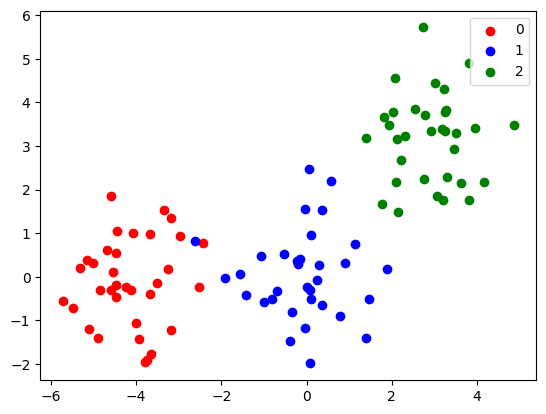

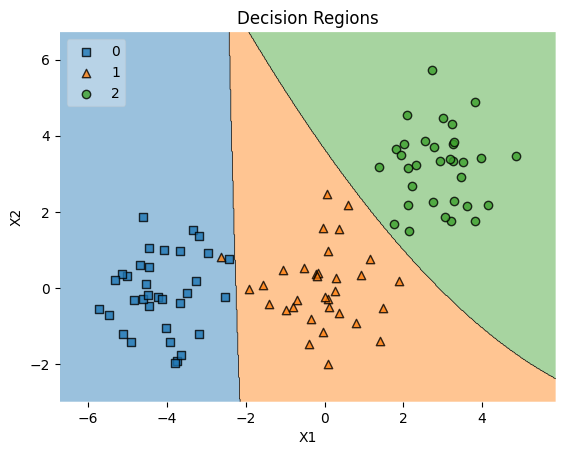

In [70]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB


# mostra os dados e colori de acordo com as classes
colors = ['red', 'blue', 'green', 'black']
aux = 0
for c in class_labels:
    ind = np.where(y == c)
    plt.scatter(X[ind,0][0], X[ind,1][0], color = colors[aux], label = c)
    aux = aux + 1
plt.legend()
plt.show()

# Training a classifier
model = GaussianNB()
model.fit(X, y)

# Plotting decision regions
plot_decision_regions(X, y, clf=model, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Decision Regions')
plt.show()

### Implementação do classificador Bayesino: código completo

In [71]:
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

random.seed(42)
# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
file_path = '/content/drive/MyDrive/data/iris.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
# classes: setosa, virginica e versicolor
############################


classes = pd.unique(data[data.columns[-1]])
classes = np.array(classes, dtype=str)
# converte para matrizes do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]
# Seleciona o conjunto de teste e treinamento
p = 0.7
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p)

# funcao para calcular a verossimilhanca
def likelyhood(y, Z):
    def gaussian(x, mu, sig):
        return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))
    prob = 1
    for j in np.arange(0, Z.shape[1]):
        m = np.mean(Z[:,j])
        s = np.std(Z[:,j])
        prob = prob*gaussian(y[j], m, s)
    return prob

# matriz que armazena o produto da verossimilhanca pela priori
P = pd.DataFrame(data=np.zeros((X_test.shape[0], len(classes))), columns = classes)
for i in np.arange(0, len(classes)):
    elements = tuple(np.where(y_train == classes[i]))
    Z = X_train[elements,:][0]
    for j in np.arange(0,X_test.shape[0]):
        x = X_test[j,:]
        pj = likelyhood(x,Z) #verossimilhanca
        pc = len(elements)/X_train.shape[0] # priori
        #P[classes[i]][j] = pj*pc
        P.loc[j, classes[i]] = pj*pc

# realiza a classificao seguindo a regra de Bayes
y_pred = []
for i in np.arange(0, P.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(P.columns[c])
y_pred = np.array(y_pred, dtype=str)
# calcula a acuracia na classificacao
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Accuracy: 0.9111111111111111


## Classificador Bayesiano paramétrico

Vamos considerar o caso paramétrico, assumindo que cada variável está distribuída de acordo com uma distribuição Normal. Outras distribuições também podem ser utilizadas.

Já selecionamos os conjuntos de treinamento e teste anteriormente. No conjunto de treinamento, vamos calcular a média e desvio padrão de cada atributo para cada classe. A seguir, reaizamos a classificação, dos dados usando a teoria da decisão Bayesiana, isto é: $X \in C_i$ se, e somente se, $P(C_i|X) = \max P(C_j|X)$ para todo $j$.

In [72]:
from scipy.stats import multivariate_normal

#matrix to store the probabilities
P = pd.DataFrame(data=np.zeros((X_test.shape[0], len(classes))), columns = classes)
Pc = np.zeros(len(classes)) #fraction of elements in each class
for i in np.arange(0, len(classes)):
    elements = np.array(np.where(y_train == classes[i]))
    Pc[i] = elements.shape[1]/len(y_train)
    Z = X_train[elements,:][0].astype(float)
    m = np.mean(Z, axis = 0)
    cv = np.cov(np.transpose(Z))
    for j in np.arange(0,X_test.shape[0]):
        x = X_test[j,:]
        pj = multivariate_normal.pdf(x, mean=m, cov=cv, allow_singular=True)
        #P[classes[i]][j] = pj*Pc[i]
        P.loc[j, classes[i]] = pj*Pc[i]

In [73]:
print(P)

           setosa    versicolor     virginica
0    4.571827e-61  1.372992e+00  3.889534e-05
1   7.014412e-130  4.419073e-03  1.885874e-01
2    1.548089e+00  1.070192e-31  9.408505e-32
3    5.267120e-03  2.273043e-28  7.386889e-28
4   3.725754e-124  1.805171e-03  7.155005e-02
5    1.676140e+00  8.723495e-30  6.955377e-32
6    3.667765e-69  5.343455e-01  3.871707e-04
7   9.888894e-137  1.285052e-08  9.497446e-02
8   2.319581e-158  4.050157e-11  2.043770e-02
9    7.787912e-90  3.821045e-01  7.976651e-03
10   2.178330e-01  1.353303e-40  3.289710e-42
11   2.319651e-72  2.803866e-01  2.033674e-04
12  1.711620e-179  5.810246e-05  5.886187e-02
13  2.945617e-137  4.036801e-04  1.413550e-01
14  5.703549e-145  1.178939e-04  2.868483e-01
15  2.399080e-153  1.608327e-11  1.364745e-03
16  1.987363e-165  3.015728e-05  2.554881e-01
17  1.266045e-150  3.899814e-05  3.325053e-01
18   1.467252e+00  8.907674e-28  2.117140e-29
19  2.332853e-157  6.000564e-16  4.149801e-02
20   1.285264e-30  7.312133e-04  4

Classifica de acordo com a classe mais provável:

In [74]:
y_pred = []
#np.array(test_x.shape[0], dtype=str)
for i in np.arange(0, X_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred)
y_test = np.array(y_test)
print(y_pred)

['versicolor' 'virginica' 'setosa' 'setosa' 'virginica' 'setosa'
 'versicolor' 'virginica' 'virginica' 'versicolor' 'setosa' 'versicolor'
 'virginica' 'virginica' 'virginica' 'virginica' 'virginica' 'virginica'
 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'setosa' 'setosa' 'versicolor' 'versicolor' 'virginica'
 'versicolor' 'setosa' 'virginica' 'setosa' 'versicolor' 'virginica'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'virginica' 'virginica'
 'setosa' 'setosa']


In [75]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.9555555555555556


## Caso não paramétrico




Para o caso unidimensional, seja $(X_1,X_2, \ldots, X_n)$ uma amostra aleatória unidimensional identicamente distribuída de acordo com alguma função de distribuição $f$ não conhecida. Para estimarmos o formato de $f$, usamos um estimador (kernel density estimator):
\begin{equation}
\widehat{f}_{h}(x)={\frac {1}{n}}\sum _{i=1}^{n}K_{h}(x-x_{i})={\frac {1}{nh}}\sum _{i=1}^{n}K{\Big (}{\frac {x-x_{i}}{h}}{\Big )},
\end{equation}
onde $K$ é a função kernel.
A estimação depende do parâmetro $h$, que é um parâmetro livre e controla a abertura da função.

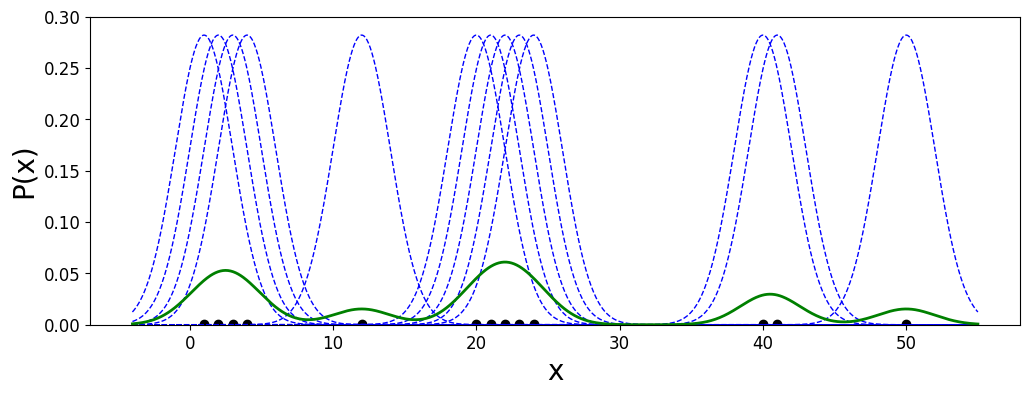

In [76]:
import numpy as np
import matplotlib.pyplot as plt

N = 20
# gera os dados
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))
# mostra os dados
plt.figure(figsize=(12,4))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

# valores x para serem usados nas densidades
X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0 # estimacao obtida
for x in X:
    # distribuição normal centrada em x
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f # acumula as distribuições
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

# mostra a distribuição estimada
plt.plot(X_plot,fhat/(len(X)*np.sqrt(h)), color = 'green', linewidth=2)
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)', fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))
plt.savefig('kernel-ex.eps')
plt.show(True)

Esse resultado pode ser obtido usando-se a função KernelDensity scikit-learn.

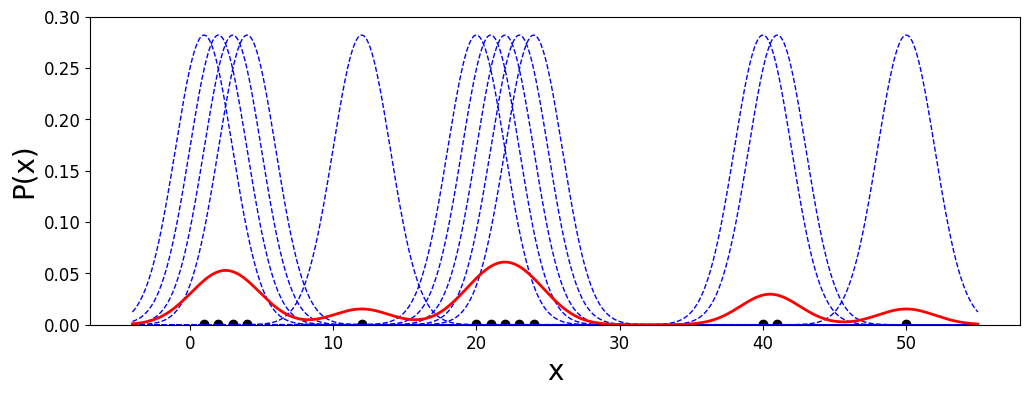

In [77]:
import numpy as np
from matplotlib.pyplot import cm
from sklearn.neighbors import KernelDensity

color=['red', 'blue', 'magenta', 'gray', 'green']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

plt.figure(figsize=(12,4))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0
for x in X:
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
plt.plot(X_plot,log_dens, color = 'red', linewidth=2, label = 'h='+str(h))
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)', fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))

plt.show(True)

Notem que o formato da estimação depende do parâmetro livre $h$.

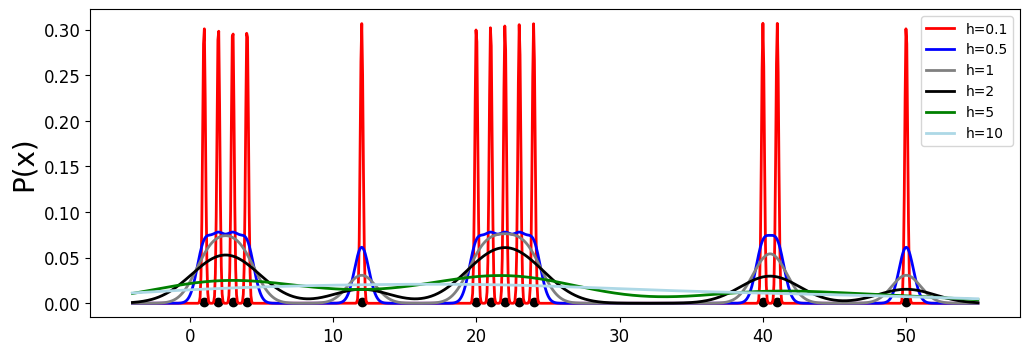

In [78]:
import numpy as np
from matplotlib.pyplot import cm

color=['red', 'blue', 'gray', 'black', 'green', 'lightblue']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

plt.figure(figsize=(12,4))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')
c = 0
vh = [0.1, 0.5, 1, 2, 5, 10]
for h in vh:
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
    log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
    plt.plot(X_plot,log_dens, color = color[c], linewidth=2, label = 'h='+str(h))
    c = c + 1
plt.ylabel('P(x)', fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.ylim((0, 0.2))
plt.legend(fontsize = 10)
#plt.savefig('kernel.eps')
plt.show(True)

Notem que a estimação é relacionada com a estimação usando-se histogramas.

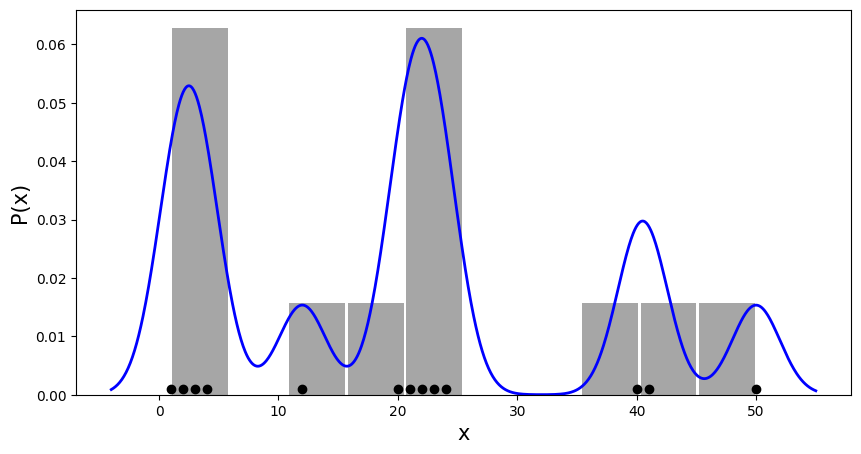

In [79]:
import numpy as np

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

plt.figure(figsize=(10,5))
# Histogram
nbins = 10
plt.hist(X,bins = nbins, density = True, color='gray',alpha=0.7, rwidth=0.95)

#Kernel density estimation
X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(X)
log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
plt.plot(X_plot,log_dens, color = 'blue', linewidth=2)
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')
plt.xlabel('x', fontsize = 15)
plt.ylabel('P(x)', fontsize = 15)

plt.show(True)

Usando o método *kernel density estimation*, podemos realizar a classificação.

In [80]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################


classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

# Matriz que armazena as probabilidades para cada classe
P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes)
Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
h = 2
for i in np.arange(0, len(classes)): # Para cada classe
    elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
    Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
    Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
    for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
        x = x_test[j,:]
        x = x.reshape((1,len(x)))
        # calcula a probabilidade pertencer a cada classe
        pj = np.exp(kde.score_samples(x))
        P.loc[j,classes[i]] = pj*Pc[i]

y_pred = [] # Vetor com as classes preditas
for i in np.arange(0, x_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred, dtype=str)
# calcula a acuracia
score = accuracy_score(y_pred, y_test)
print('Acuracia:', score)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Comp  Circ  D.Circ  Rad.Ra  Pr.Axis.Ra  Max.L.Ra  Scat.Ra  Elong  \
0    95    48      83     178          72        10      162     42   
1    91    41      84     141          57         9      149     45   
2   104    50     106     209          66        10      207     32   
3    93    41      82     159          63         9      144     46   
4    85    44      70     205         103        52      149     45   

   Pr.Axis.Rect  Max.L.Rect  Sc.Var.Maxis  Sc.Var.maxis  Ra.Gyr  Skew.Maxis  \
0            20         159           176           379     184          70   
1            19         143           170           330     158          72   
2            23         158           223           635     220          73   
3            19         143           160           309     127          63   
4            19         144           241      

Notem que a acurácia depende do parâmetro $h$, conforme verficamos abaixo.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Comp  Circ  D.Circ  Rad.Ra  Pr.Axis.Ra  Max.L.Ra  Scat.Ra  Elong  \
0    95    48      83     178          72        10      162     42   
1    91    41      84     141          57         9      149     45   
2   104    50     106     209          66        10      207     32   
3    93    41      82     159          63         9      144     46   
4    85    44      70     205         103        52      149     45   

   Pr.Axis.Rect  Max.L.Rect  Sc.Var.Maxis  Sc.Var.maxis  Ra.Gyr  Skew.Maxis  \
0            20         159           176           379     184          70   
1            19         143           170           330     158          72   
2            23         158           223           635     220          73   
3            19         143           160           309     127          63   
4            19         144           241      

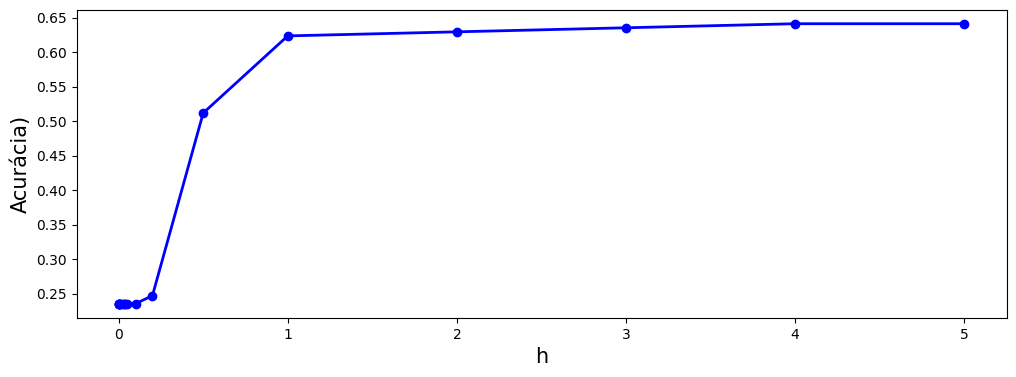

In [81]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score

random.seed(42)

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

####  Realiza a classificacao ####
vacc = []
vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2,3,4, 5]
plt.figure(figsize=(12,4))
for h in vh:
    # Matriz que armazena as probabilidades para cada classe
    P = pd.DataFrame(data=np.zeros((x_train.shape[0], len(classes))), columns = classes)
    Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
    for i in np.arange(0, len(classes)): # Para cada classe
        elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
        Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
        Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
        kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
        for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
            x = x_test[j,:]
            x = x.reshape((1,len(x)))
            # calcula a probabilidade pertencer a cada classe
            pj = np.exp(kde.score_samples(x))
            P.loc[j,classes[i]] = pj*Pc[i]

    y_pred = [] # Vetor com as classes preditas
    for i in np.arange(0, x_test.shape[0]):
        c = np.argmax(np.array(P.iloc[[i]]))
        y_pred.append(classes[c])
    y_pred = np.array(y_pred, dtype=str)
    # calcula a acuracia
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
    #print('Acuracia:', score)

plt.plot(vh,vacc, 'o-', color = 'blue', linewidth=2)
plt.xlabel('h', fontsize = 15)
plt.ylabel('Acurácia)', fontsize = 15)
plt.show(True)

## **Exercícios para entregar**

## **Ex1**

 - Faça a classificação da base BreastCancer usando o classificador Naive Bayes.

In [82]:
#bibliotecas
from sklearn.model_selection import train_test_split

In [83]:
#carregando a base de dados
cancer_file_path = "/content/drive/MyDrive/data/BreastCancer.csv"
data_cancer =  pd.read_csv(cancer_file_path)

#limpando os Nan
data_cancer = data_cancer.dropna(axis="rows")

#armazena as classes
classes_cancer = np.array(pd.unique(data_cancer[data_cancer.columns[-1]]), dtype=str)

print("nro de linhas e colunas namatriz de atributos: ", data_cancer.shape)
atrubutos = list(data_cancer.columns)
data_cancer.head(10)



nro de linhas e colunas namatriz de atributos:  (683, 11)


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
5,1017122,8,10,10,8,7,10.0,9,7,1,1
6,1018099,1,1,1,1,2,10.0,3,1,1,0
7,1018561,2,1,2,1,2,1.0,3,1,1,0
8,1033078,2,1,1,1,2,1.0,1,1,5,0
9,1033078,4,2,1,1,2,1.0,2,1,1,0


In [84]:
#transformano em objt numpy
data_cancer = data_cancer.to_numpy()
n_linha, n_colunas = data_cancer.shape

#dividindo os dato em excemplos de entrada e saidas esperadas
y = data_cancer[:, -1] #a utlima coluna
X = data_cancer[:, 0:n_colunas-1] # os exemplos de entrada de {0,n_colunas-1}

#selecionando os dados de treinamento e teste
p=0.7
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=p, random_state=42)

#Importando o classificador
model = GaussianNB()
model.fit(X_train, y_train) #ajustando os parametros de teste e treinamento

#predizendo
y_pred = model.predict(X_test)
score_cancer = accuracy_score(y_pred, y_test)

print("A acurácia obtida foi de: ", score_cancer)



A acurácia obtida foi de:  0.8926829268292683


## EX2

Considere a base vertebralcolumn-3C e compare o classificadores: Naive Bayes, Classificador Bayesiano paramétrico e o classiificador Bayesiano não-paramétrico.

In [85]:
#carregando a base de dados
coluna_file_path = "/content/drive/MyDrive/data/vertebralcolumn-3C.csv"
data_coluna =  pd.read_csv(coluna_file_path)

#limpando os Nan
data_coluna = data_coluna.dropna(axis="rows")

#armazena as classes
classes_coluna = np.array(pd.unique(data_coluna[data_coluna.columns[-1]]), dtype=str)
print("Classes presentes no conjunto: ", classes_coluna)
print("nro de linhas e colunas namatriz de atributos: ", data_coluna.shape)
atrubutos = list(data_coluna.columns)
data_coluna.head(10)


Classes presentes no conjunto:  ['Hernia' 'Spondylolisthesis' 'Normal']
nro de linhas e colunas namatriz de atributos:  (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,Hernia
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Hernia
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Hernia


### Aplicando Naive Bayes

In [86]:

#transformano em objt numpy
data_coluna = data_coluna.to_numpy()
n_linha, n_colunas = data_coluna.shape

#dividindo os dato em excemplos de entrada e saidas esperadas
y_coluna = data_coluna[:, -1] #a utlima coluna
X_coluna = data_coluna[:, 0:n_colunas-1] # os exemplos de entrada de {0,n_colunas-1}

#selecionando os dados de treinamento e teste
p=0.7
X_train_coluna, X_test_coluna, y_train_coluna, y_test_coluna = train_test_split(X_coluna,y_coluna, train_size=p, random_state=42)

#Importando o classificador
model = GaussianNB()
model.fit(X_train_coluna, y_train_coluna) #ajustando os parametros de teste e treinamento

#predizendo
y_pred_coluna = model.predict(X_test_coluna)
score_coluna = accuracy_score(y_pred_coluna, y_test_coluna)

print("A acurácia obtida foi de: ", score_coluna)


A acurácia obtida foi de:  0.7849462365591398


### Aplicando o classificador Bayesiano Paramétrico

In [87]:
from scipy.stats import multivariate_normal

P_coluna = pd.DataFrame(data = np.zeros((X_test_coluna.shape[0],len(classes_coluna))), columns= classes_coluna)
P_c_coluna = np.zeros(len(classes_coluna))

for i in np.arange(0,len(classes_coluna)):
  elementos= np.array(np.where(y_train_coluna == classes_coluna[i])) #PEGA os indices das amostra de acordo com a classe i
  P_c_coluna[i] = elementos.shape[1]/len(y_train_coluna)
  Z = X_train_coluna[elementos, :][0].astype(float) #pga somente os elementos correspondentes
  media = np.mean(Z, axis=0) #axis  0 = por coluna
  covariancia = np.cov(np.transpose(Z))

  for j in np.arange(0, X_test_coluna.shape[0]):
    x_coluna = X_test_coluna[j, :]
    pj_coluna = multivariate_normal.pdf(x_coluna, mean=media, cov=covariancia, allow_singular=True)
    P_coluna[classes_coluna[i]][j] = pj_coluna*P_c_coluna[i]


/tmp/ipykernel_164/1730581172.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  P_coluna[classes_coluna[i]][j] = pj_coluna*P_c_coluna[i]


In [88]:
print(P_coluna)

          Hernia  Spondylolisthesis        Normal
0   3.183997e-09       7.115327e-11  1.940077e-08
1   8.857104e-14       1.331887e-11  5.808737e-18
2   5.730974e-08       3.629630e-10  3.725095e-08
3   1.207570e-35       3.216952e-10  3.558622e-25
4   2.578931e-08       8.812849e-11  2.114334e-09
..           ...                ...           ...
88  2.333779e-12       4.397352e-10  3.490203e-13
89  2.384078e-12       1.930661e-11  6.408506e-09
90  3.914626e-08       1.435410e-10  2.176713e-08
91  2.589850e-45       1.330860e-09  7.414347e-29
92  2.603762e-11       5.712203e-10  2.571719e-10

[93 rows x 3 columns]


In [89]:
#classificando de acordo com a maior probabilidade
y_pred_coluna_bp  = []

for i in np.arange(0, X_test_coluna.shape[0]):
  c = np.argmax(np.array(P_coluna.iloc[[i]]))
  y_pred_coluna_bp.append(classes_coluna[c])

y_pred_coluna_bp = np.array(y_pred_coluna_bp)
y_test_coluna_bp = np.array(y_test_coluna)
print(y_pred_coluna_bp)

['Normal' 'Spondylolisthesis' 'Hernia' 'Spondylolisthesis' 'Hernia'
 'Spondylolisthesis' 'Spondylolisthesis' 'Spondylolisthesis' 'Hernia'
 'Hernia' 'Spondylolisthesis' 'Spondylolisthesis' 'Normal' 'Normal'
 'Normal' 'Hernia' 'Normal' 'Spondylolisthesis' 'Spondylolisthesis'
 'Spondylolisthesis' 'Spondylolisthesis' 'Spondylolisthesis'
 'Spondylolisthesis' 'Spondylolisthesis' 'Spondylolisthesis'
 'Spondylolisthesis' 'Spondylolisthesis' 'Normal' 'Normal' 'Normal'
 'Spondylolisthesis' 'Normal' 'Spondylolisthesis' 'Normal'
 'Spondylolisthesis' 'Spondylolisthesis' 'Hernia' 'Normal'
 'Spondylolisthesis' 'Spondylolisthesis' 'Normal' 'Hernia'
 'Spondylolisthesis' 'Normal' 'Normal' 'Spondylolisthesis' 'Normal'
 'Normal' 'Hernia' 'Spondylolisthesis' 'Spondylolisthesis' 'Normal'
 'Spondylolisthesis' 'Spondylolisthesis' 'Spondylolisthesis'
 'Spondylolisthesis' 'Hernia' 'Spondylolisthesis' 'Spondylolisthesis'
 'Hernia' 'Spondylolisthesis' 'Spondylolisthesis' 'Spondylolisthesis'
 'Spondylolisthesis' '

In [90]:
#calculando a precisão
score_coluna_bp = accuracy_score(y_pred_coluna_bp, y_test_coluna)
print("A acurácia obtivda com Bayesino Paramétrico foi: ", score_coluna_bp)

A acurácia obtivda com Bayesino Paramétrico foi:  0.8064516129032258


### Aplicando o classificador Bayesiano Não-Paramétrico

Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.1935483870967742
Acurácia do Mét. Não-Paramétrico: 0.27956989247311825
Acurácia do Mét. Não-Paramétrico: 0.6989247311827957
Acurácia do Mét. Não-Paramétrico: 0.8279569892473119
Acurácia do Mét. Não-Paramétrico: 0.8387096774193549
Acurácia do Mét. Não-Paramétrico: 0.8064516129032258
Acurácia do Mét. Não-Paramétrico: 0.8064516129032258
Acurácia do Mét. Não-Paramétrico: 0.8064516129032258


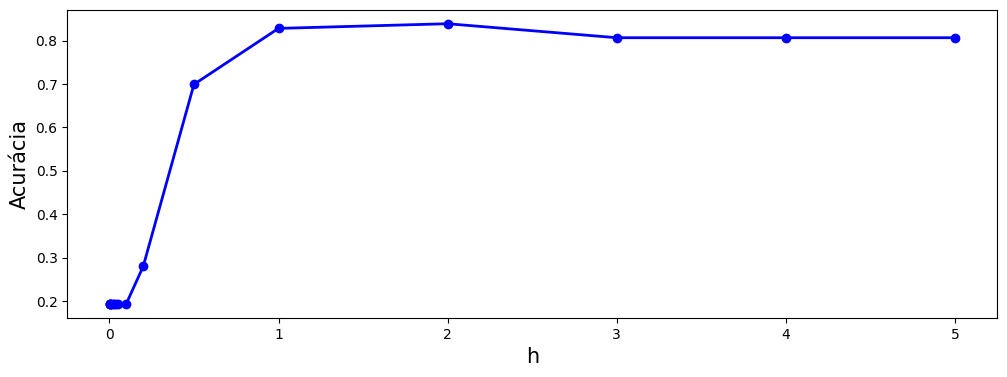

In [91]:
# aplicando o classificador
random.seed(42)

vacc = []
vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2,3,4, 5]
plt.figure(figsize=(12,4))
plt.ylabel('Acurácia', fontsize=15)

for h in vh:

    # Matriz que armazena as probabilidades para cada classe
    P_coluna = pd.DataFrame(
        data=np.zeros((X_test_coluna.shape[0], len(classes_coluna))),
        columns=classes_coluna
    )

    P_c_coluna = np.zeros(len(classes_coluna))  # fração de elementos em cada classe

    for i in np.arange(0, len(classes_coluna)):  # para cada classe

        elementos = np.where(y_train_coluna == classes_coluna[i])[0]

        # probabilidade a priori da classe
        P_c_coluna[i] = len(elementos) / len(y_train_coluna)

        # elementos da classe no treino
        Z = X_train_coluna[elementos, :].astype(float)

        kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)

        for j in np.arange(0, X_test_coluna.shape[0]):  # para cada observação de teste

            x = X_test_coluna[j, :].reshape(1, -1)

            # probabilidade da classe
            pj_coluna = np.exp(kde.score_samples(x))

            P_coluna.loc[j, classes_coluna[i]] = pj_coluna * P_c_coluna[i]

    # classes preditas
    y_pred_np = []

    for i in np.arange(0, X_test_coluna.shape[0]):

        c = np.argmax(P_coluna.iloc[i].values)
        y_pred_np.append(classes_coluna[c])

    y_pred_np = np.array(y_pred_np, dtype=str)

    # acurácia
    score_np = accuracy_score(y_test_coluna, y_pred_np)
    vacc.append(score_np)

    print('Acurácia do Mét. Não-Paramétrico:', score_np)


plt.plot(vh, vacc, 'o-', color='blue', linewidth=2)
plt.xlabel('h', fontsize=15)
plt.ylabel('Acurácia', fontsize=15)
plt.show()

## Ex3

 Implemente uma versão do classificador Bayesiano usando orientação ao objeto. Implemente os métodos fit e predict.

In [92]:
class Bayesiano():
  def __init__(self):
    self.x_train = None
    self.y_train = None


  def fit(self, train_x, train_y):
    self.x_train = train_x
    self.y_train = train_y


  def probabilidades(self, test_x, classes):
    tam_classes = len(classes)
    P = pd.DataFrame(data = np.zeros((test_x.shape[0],tam_classes)), columns= classes)
    P_c = np.zeros(tam_classes)

    for i in np.arange(0,tam_classes):
      elementos = np.where(self.y_train == classes[i])[0]
      P_c[i] = len(elementos) / len(self.y_train)
      Z = self.x_train[elementos, :].astype(float)
      media = np.mean(Z, axis=0) #axis  0 = por coluna
      covariancia = np.cov(np.transpose(Z))

      for j in np.arange(0, test_x.shape[0]):
        x = test_x[j, :]
        pj = multivariate_normal.pdf(x, mean=media, cov=covariancia, allow_singular=True)
        P.loc[j, classes[i]] = pj * P_c[i]

    return P

  def predict(self, test_x, P, modo, classes):
    if modo == 'BP':
      y_pred_bp  = []

      for i in np.arange(0, test_x.shape[0]):
        c = np.argmax(P.iloc[i].values)
        y_pred_bp.append(classes[c])

      y_pred_bp = np.array(y_pred_bp)

      return y_pred_bp

    else:
        random.seed(42)
        tam_classes = len(classes)
        vacc = []
        vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2,3,4, 5]

        for h in vh:

            # Matriz que armazena as probabilidades para cada classe
            P = pd.DataFrame(
                data=np.zeros((test_x.shape[0], tam_classes)),
                columns=classes
            )

            P_c = np.zeros(tam_classes)  # fração de elementos em cada classe

            for i in np.arange(0, tam_classes):  # para cada classe

                elementos = np.where(self.y_train == classes[i])[0]

                # probabilidade a priori da classe
                P_c[i] = len(elementos) / len(self.y_train)

                # elementos da classe no treino
                Z = self.x_train[elementos, :].astype(float)

                kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)

                for j in np.arange(0, test_x.shape[0]):  # para cada observação de teste

                    x = test_x[j, :].reshape(1, -1)

                    # probabilidade da classe
                    pj = np.exp(kde.score_samples(x))

                    P.loc[j, classes[i]] = pj * P_c[i]

            # classes preditas
            y_pred_np = []

            for i in np.arange(0, test_x.shape[0]):

                c = np.argmax(P.iloc[i].values)
                y_pred_np.append(classes[c])

            y_pred_np = np.array(y_pred_np)

            # acurácia
            score_np = accuracy_score(y_test, y_pred_np)
            vacc.append(score_np)

        return y_pred_np, vh, vacc, score_np

  def score(self, y_test, pred):
      # acurácia
      score_ = accuracy_score(y_test, pred)
      print("A acuracia foi de: ", score_)


Demonstração do uso da classe Bayesiano

In [93]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()

#acessado os dados
x = iris.data
y = iris.target

#visualizando os dados pelo pandas
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = iris.target_names[y]

# Print information (optional)
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of the DataFrame:")
print(df.head())

Features (X) shape: (683, 10)
Target (y) shape: (150,)
First 5 rows of the DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [94]:
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,shuffle=True)

In [95]:
#aplicando o bayesiano
modelo = Bayesiano()


#aplicando o fit
modelo.fit(X_train, y_train)

#classes do iris
classes_iris = np.unique(y_train)

#vetor de probabilidades
vetor_p = modelo.probabilidades(X_test, classes_iris)

#paramétrico
y_pred_bp = modelo.predict(X_test, vetor_p, "BP", classes_iris)

#não-paramétrico
y_pred_np, vh, vacc, score_np = modelo.predict(X_test, vetor_p, "NP", classes_iris)

#avaliação
modelo.score(y_test, y_pred_bp)
modelo.score(y_test, y_pred_np)

A acuracia foi de:  0.9666666666666667
A acuracia foi de:  0.8


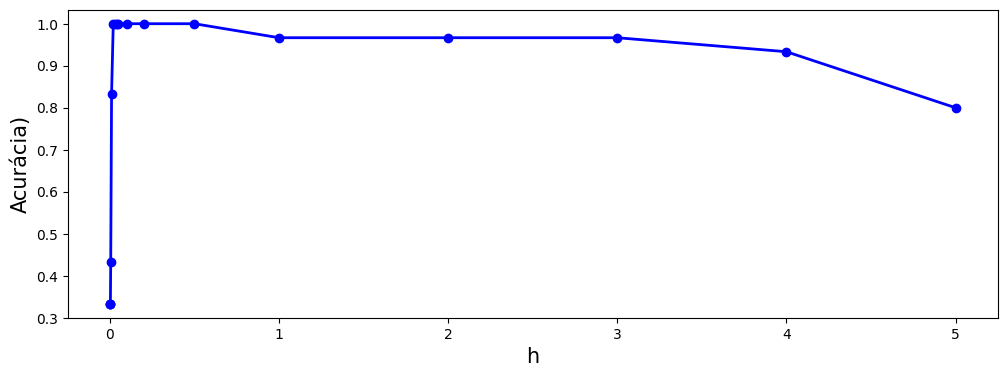

In [96]:
plt.figure(figsize=(12,4))
plt.plot(vh,vacc, 'o-', color = 'blue', linewidth=2)
plt.xlabel('h', fontsize = 15)
plt.ylabel('Acurácia)', fontsize = 15)
plt.show(True)

## Ex4

4 - Verifique essa propriedade: Apesar da limitação em assumir independência dos atributos, o classificador Naive Bayes é robusto.

Gere dados com diferentes níveis de correlação entre as variáveis e verifique se a perfomance do algoritmo Naive Bayes muda com a correlação.

In [97]:
def gerar_dados(n_amostras=2000, n_features=5, cvr=0.0):
  #matriz de covariancia
  cov = np.full((n_features,n_features), cvr)
  np.fill_diagonal(cov,1)

  #classe 1
  #np.random.multivariante_normal= gera amostras aleatórias de uma distrib normal multivariada
  c1 = np.random.multivariate_normal(mean=np.zeros(n_features), cov=cov, size=n_amostras//2)

  #classe 2
  c2 = np.random.multivariate_normal(mean=np.ones(n_features), cov=cov, size=n_amostras//2)

  x = np.vstack([c1,c2])
  y = np.array([0] * (n_amostras//2) + [1]*(n_amostras//2))

  return x, y


In [98]:
#criando o teste com diferente niveis de correlação
correlacoes = [0.0, 0.01, 0.1,0.2, 0.35, 0.5,0.7, 0.85, 0.9,1.0]
score = []
for elem in correlacoes:
  x,y = gerar_dados(cvr=elem)

  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

  #Importando o classificador
  model = GaussianNB()
  model.fit(x_train, y_train) #ajustando os parametros de teste e treinamento

  #predizendo
  y_pred = model.predict(x_test)
  scr= accuracy_score(y_test, y_pred)
  score.append(scr)
  print("A correlacao obtida foi de: ", elem)
  print("A acurácia obtida foi de: ", scr)

A correlacao obtida foi de:  0.0
A acurácia obtida foi de:  0.8766666666666667
A correlacao obtida foi de:  0.01
A acurácia obtida foi de:  0.8316666666666667
A correlacao obtida foi de:  0.1
A acurácia obtida foi de:  0.8433333333333334
A correlacao obtida foi de:  0.2
A acurácia obtida foi de:  0.7666666666666667
A correlacao obtida foi de:  0.35
A acurácia obtida foi de:  0.74
A correlacao obtida foi de:  0.5
A acurácia obtida foi de:  0.7466666666666667
A correlacao obtida foi de:  0.7
A acurácia obtida foi de:  0.755
A correlacao obtida foi de:  0.85
A acurácia obtida foi de:  0.6933333333333334
A correlacao obtida foi de:  0.9
A acurácia obtida foi de:  0.6883333333333334
A correlacao obtida foi de:  1.0
A acurácia obtida foi de:  0.7133333333333334


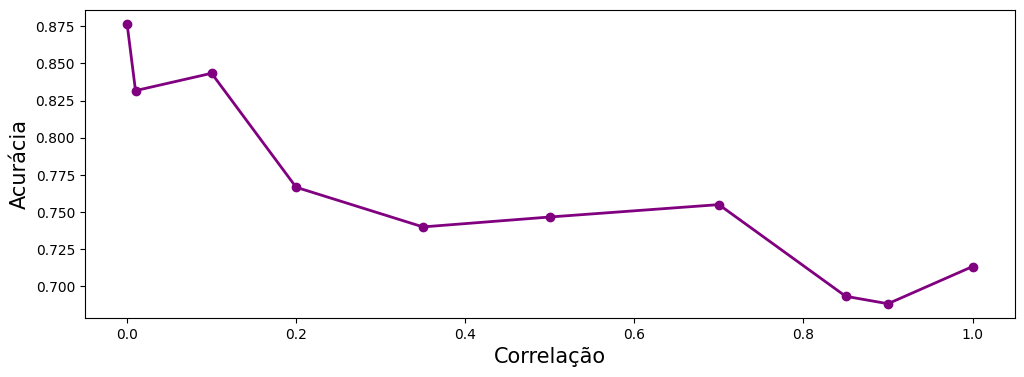

In [99]:
plt.figure(figsize=(12,4))

plt.plot(correlacoes, score, 'o-', color='purple', linewidth=2)

plt.xlabel('Correlação', fontsize=15)
plt.ylabel('Acurácia', fontsize=15)

plt.show()

## Ex5

5 - Implemente o Naive Bayes sem usar o scik-learn. Use distribuições de probabilidade diferentes da normal.

In [102]:
class Bayes():
  def __init__(self):
    self.x_train = None
    self.y_train = None
    self.type_distrib = None

  def fit(self, x_train, y_train, tipo):
    self.x_train = x_train
    self.y_train = y_train
    self.modo = tipo

  def bernoulli(self,p, k):
    if (k == 1 or k == 0 )and (p>=0.0 or p<=1.0):
      f_p = (p**k )*((1-p)**(1-k))
      return f_p
    else:
      print("Valores Invalidos")
      return None

  def gaussian(self,x, mu, sig):
        p = (1/np.sqrt(2*np.pi*sig))*np.exp((-1/2)*((x-mu)/sig)**2)
        return p
  def verossimilhanca(self,amostra, Z):
    #Z: os dados de treino de uma classe
    if self.modo == "Gaussiano":
        lk = 1
        for j in np.arange(0, Z.shape[1]):
            m = np.mean(Z[:,j])
            s = np.std(Z[:,j])
            lk = lk*self.gaussian(amostra[j], m, s)
        return lk
    elif self.modo == "Bernoulli":
        lk = 1
        count = 1
        for j in np.arange(0, Z.shape[1]):
          #a probabilidade da featurej ser 1 dado que a classe é c_i
          p_j = np.mean(Z[:, j]) #como temos 0 e 1, conseguimos usar a media

          if p_j == 0: #caso, onde tudo é 0
            count = np.sum(Z[:, j] == 1) #qtd de 1
            n = Z.shape[0]
            p_j = (count+1)/(n+2) #laplace smoothing
          k = amostra[j]
          prob_b = self.bernoulli(p_j, k)
          lk = lk * prob_b #calcula o produtorio das probabilidades
        return lk

  def estimando_classes(self, x_test,classes):
    P = pd.DataFrame(
                data=np.zeros((x_test.shape[0], len(classes))),
                columns=classes
            )
    for i in np.arange(0, len(classes)):
      elementos = tuple(np.where(self.y_train == classes[i]))
      Z = self.x_train[elementos,:][0]
      for j in np.arange(0,x_test.shape[0]):
          x = x_test[j,:]
          pj = self.verossimilhanca(x,Z)
          priori = len(elementos)/self.x_train.shape[0]
          P.loc[j,classes[i]] = pj*Pc[i]
    return P

  def predict(self, x_test, P):
    y_pred = []
    for i in np.arange(0, P.shape[0]):
        c = np.argmax(np.array(P.iloc[[i]]))
        y_pred.append(P.columns[c])
    #y_pred = np.array(y_pred, dtype=str)

    return y_pred

  def score(self, y_test, pred):
      # acurácia
      score_ = accuracy_score(y_test, pred)
      print("A acuracia foi de: ", score_)


In [103]:

X_train = np.array([
    [1,0,1],
    [1,1,1],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0]
])

y_train = np.array([-1,1,-1,1,1,-1])

# uma amostra de teste
x_test = np.array([[1,0,1]])

modelo = Bayes()

modelo.fit(X_train, y_train, "Bernoulli")

classes = np.unique(y_train)

Prob = modelo.estimando_classes(x_test, classes)

print("Tabela de probabilidades:")
print(Prob)

Y_pred = modelo.predict(x_test, Prob)

print("Predição:", Y_pred)

# valor real para teste
y_test = np.array([-1])

modelo.score(y_test, Y_pred)

Tabela de probabilidades:
         -1    1
0  0.000526  0.0
Predição: [np.int64(-1)]
A acuracia foi de:  1.0
